# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

This project is a predictive modeling and feature engineering problem. 

This might involves exploratory data analysis, use of regression models, and supervised learning to determine which factors significantly increase or decrease a car’s selling price and to generate actionable insights for pricing strategy.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [223]:
#Libraries, to be maintained at the top as we go along 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score


In [37]:
#Load the dataset & inspect basic structure
df = pd.read_csv("data/vehicles.csv")

#preview data 
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [12]:
#details and datatypes review
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [20]:
# Count missing values per column
#df.isnull().sum() 

# Percentage missing - this gives a better view of the missing values
(df.isnull().sum() / len(df)) * 100

id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64

In [228]:
# sanity checks
#df[df['price'] <= 0].head()

print((df['price'] <= 0).sum())

# Year -- Good
print(df[df['year'] > 2026].head())

# Mileage -- Good
print(df[df['odometer'] < 0].head())


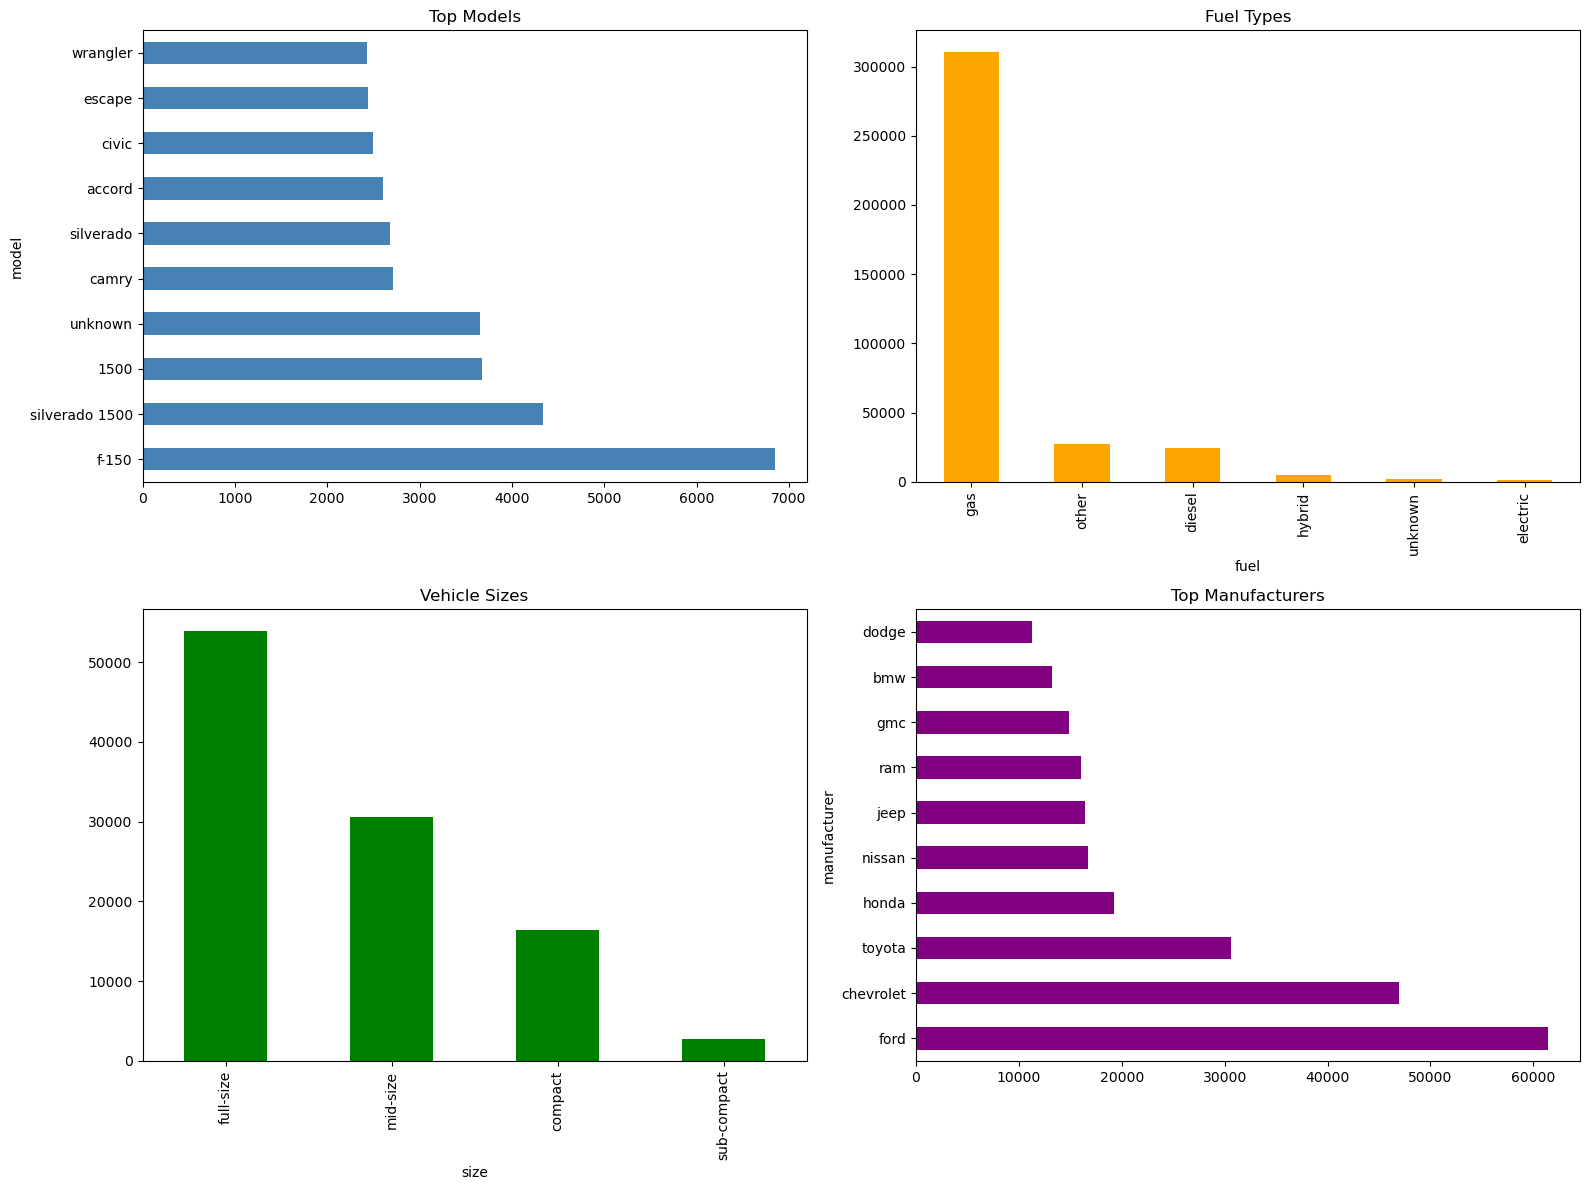

In [234]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

df['model'].value_counts().head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top Models')

df['fuel'].value_counts().plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Fuel Types')

df['size'].value_counts().plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Vehicle Sizes')

df['manufacturer'].value_counts().head(10).plot(kind='barh', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top Manufacturers')

plt.tight_layout()
plt.show()


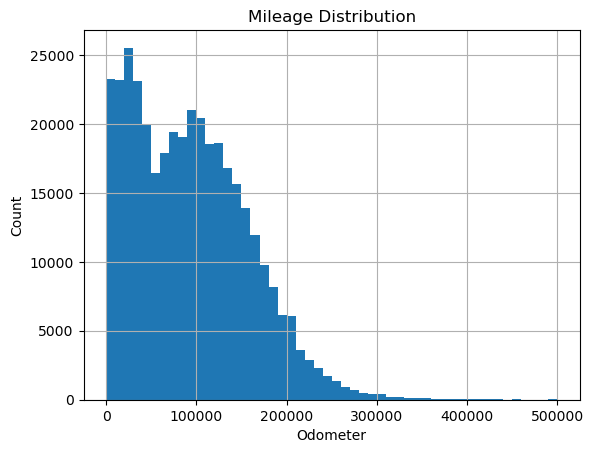

In [238]:
df['odometer'].hist(bins=50)
plt.title("Mileage Distribution")
plt.xlabel("Odometer")
plt.ylabel("Count")
plt.show()


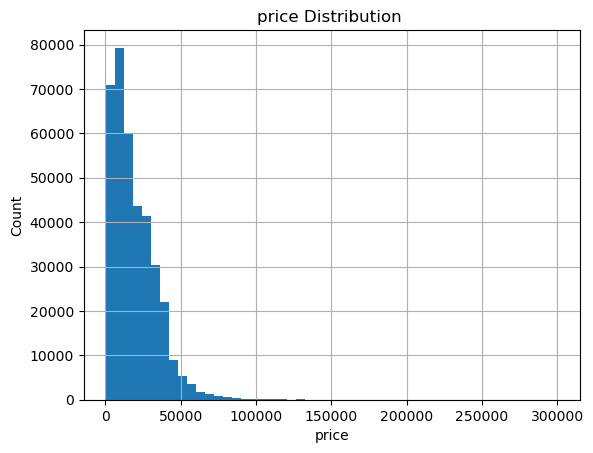

In [237]:
df['price'].hist(bins=50)
plt.title("price Distribution ")
plt.xlabel("price")
plt.ylabel("Count")
plt.show()


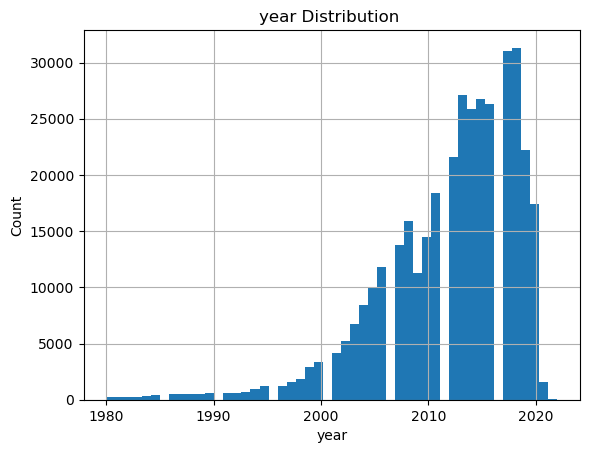

In [240]:
df['year'].hist(bins=50)
plt.title("year Distribution ")
plt.xlabel("year")
plt.ylabel("Count")
plt.show()


,price,year,odometer
price,1.000000,-0.004925,0.010032
year,-0.004925,1.000000,-0.157215
odometer,0.010032,-0.157215,1.000000


In [56]:
# Unrealistic price thresholds
df[(df['price'] < 500) | (df['price'] > 300000)].head()

# Mileage anomalies
print(df[df['odometer'] > 500000].head())

# Missing critical fields
#critical_missing = df[df[['price','year','odometer']].isnull().any(axis=1)]
#critical_missing.head()


             id      region      price    year manufacturer         model  \
280  7315849335  birmingham  987654321  1960.0    chevrolet           NaN   
455  7314165149  birmingham      22500  1929.0         ford           NaN   
562  7313478091  birmingham      27990  2014.0          ram      2500 4x4   
615  7312878239  birmingham          0  2014.0          ram  2500 slt 4x4   
616  7312876423  birmingham      17990  2018.0         ford      edge sel   

    condition    cylinders    fuel   odometer title_status transmission  VIN  \
280       NaN          NaN     gas   999999.0        clean       manual  NaN   
455       NaN          NaN     gas  9999999.0        clean    automatic  NaN   
562  like new  6 cylinders  diesel  2222222.0        clean    automatic  NaN   
615  like new  6 cylinders  diesel  1111111.0        clean    automatic  NaN   
616  like new  6 cylinders     gas  1111111.0        clean    automatic  NaN   

    drive       size   type paint_color state  
280   Na

In [241]:
summary = pd.concat({
    "missing_values": df.isnull().sum(),
    "price_stats": df['price'].describe(),
    "year_stats": df['year'].describe(),
    "odometer_stats": df['odometer'].describe(),
    "top_manufacturers": df['manufacturer'].value_counts().head(10)
}, axis=1)

summary


,missing_values,price_stats,year_stats,odometer_stats,top_manufacturers
id,0.0,NaN,NaN,NaN,NaN
region,0.0,NaN,NaN,NaN,NaN
price,0.0,NaN,NaN,NaN,NaN
year,0.0,NaN,NaN,NaN,NaN
manufacturer,0.0,NaN,NaN,NaN,NaN
model,0.0,NaN,NaN,NaN,NaN
condition,140223.0,NaN,NaN,NaN,NaN
cylinders,151762.0,NaN,NaN,NaN,NaN
fuel,0.0,NaN,NaN,NaN,NaN
odometer,0.0,NaN,NaN,NaN,NaN


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [59]:
df_raw = df.copy()

In [69]:
# Remove listings with missing critical fields
df = df.dropna(subset=["price", "year", "odometer"])

# Remove outliers
df = df[(df["price"] > 500) & (df["price"] < 300000)]
df = df[(df["year"] >= 1980) & (df["year"] <= 2026)]
df = df[(df["odometer"] >= 0) & (df["odometer"] <= 500000)]
df['body'] = df['size'].astype(str) + '_' + df['type'].astype(str)

df.shape

(371618, 19)

In [86]:
# make the data standardized 
df["model"] = df["model"].str.lower().str.strip()
df["fuel"] = df["fuel"].str.lower().str.strip()
df["body"] = df["body"].str.lower().str.strip()

#remove Vin 
df = df.drop(columns='VIN')


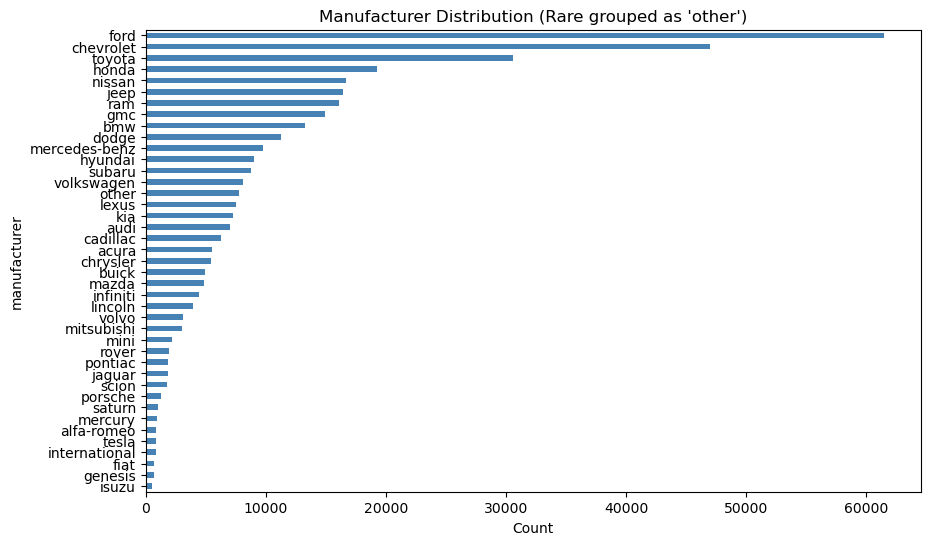

In [243]:
# removed rare categories using 100 as areference, but Harley Davidson shows up, which doesnt make cars so chaging it to 500
manufacturer_counts = df["manufacturer"].value_counts()

rare_manufacturers = manufacturer_counts[manufacturer_counts < 500].index

df["manufacturer"] = df["manufacturer"].replace(rare_manufacturers, "other")

#df["manufacturer"].value_counts()

plt.figure(figsize=(10,6))
manufacturer_counts.plot(kind='barh', color='steelblue')
plt.title("Manufacturer Distribution (Rare grouped as 'other')")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()


In [187]:
# the final mode resulted in giving trucks and kuxury cars as top performers because they all belong to the manufacture 'unknown'. Here we need to derivethe manufacturer name from the model feature and run the Model again.
df.loc[df['manufacturer'].isna() | (df['manufacturer'] == 'unknown'),'manufacturer'] = df['model'].str.split().str[0]
df['manufacturer'] = df['manufacturer'].str.lower().str.strip()

In [188]:
#furthemore the analysis resulted in giving trucks as a top category, wheras we are working on the case for a car dealership. 
df = df[~df['model'].str.contains("kenworth|peterbilt|freightliner", case=False)]

#also, mark luxury brands as such 
luxury_brands = ["rolls", "lamborghini", "bentley", "aston", "maserati"]
df.loc[df['manufacturer'].isin(luxury_brands), 'manufacturer'] = "luxury"


In [189]:
#New Features and drop , might useful in predictions : 
df["age"] = 2026 - df["year"]
df["miles_per_year"] = df["odometer"] / df["age"].replace(0, np.nan)
df["log_price"] = np.log(df["price"])

In [190]:
#df['condition'].unique()
#df[df['condition'].isnull()]

condition_map = {"new": 5,"like new": 4,"excellent": 3,"good": 2,"fair": 1, "salvage": 0}

df["condition_num"] = df["condition"].map(condition_map)

In [191]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

corr = df[numeric_cols].corr()['price'].sort_values(ascending=False)
print(corr)

price             1.000000
log_price         0.868377
year              0.535259
condition_num    -0.040863
id               -0.073742
miles_per_year   -0.304535
odometer         -0.522982
age              -0.535259
Name: price, dtype: float64


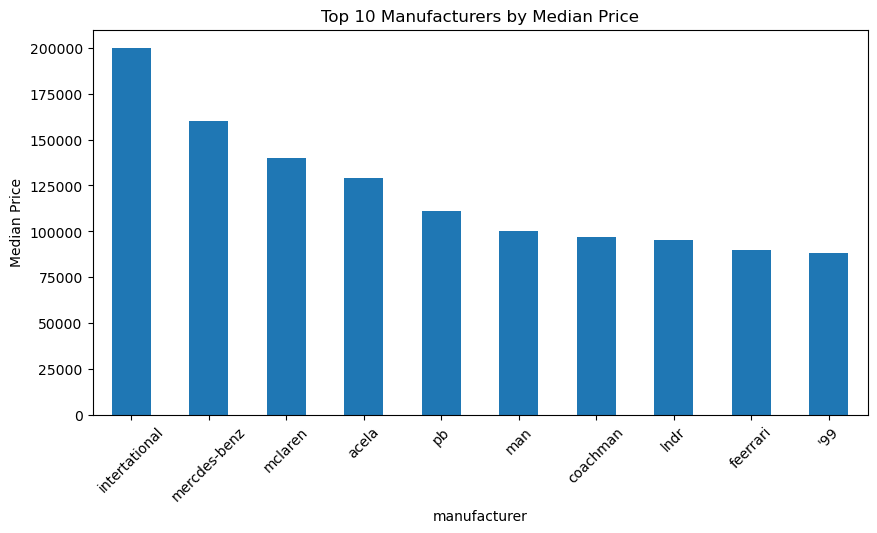

In [192]:
df.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(10)

median_prices = df.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(10)

median_prices.plot(kind='bar', figsize=(10,5), title='Top 10 Manufacturers by Median Price')
plt.ylabel('Median Price')
plt.xticks(rotation=45)
plt.show()



In [198]:
#df.query("manufacturer == 'pb'").head(50)
df[df['manufacturer'] == 'pb'][['manufacturer','model','price']].head()
#Drop all rows with manufacturer = 'pb'
df = df[df['manufacturer'] != 'pb']


In [199]:
df.query("manufacturer == 'international'").head(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,drive,size,type,paint_color,state,body,age,miles_per_year,log_price,condition_num
476,7313935156,birmingham,18800,2000.0,international,international 4700 dump,NaN,8 cylinders,diesel,193348.0,...,rwd,NaN,NaN,white,al,nan_nan,26.0,7436.461538,9.841612,NaN
798,7311384972,birmingham,29990,2012.0,international,international terrastar,good,8 cylinders,diesel,39013.0,...,rwd,full-size,truck,white,al,full-size_truck,14.0,2786.642857,10.308619,2.0
848,7311381633,birmingham,29990,2012.0,international,international terrastar,good,8 cylinders,diesel,39013.0,...,rwd,full-size,truck,white,al,full-size_truck,14.0,2786.642857,10.308619,2.0
1266,7306897364,birmingham,27990,2013.0,international,international terrastar,good,8 cylinders,diesel,138071.0,...,rwd,NaN,NaN,white,al,nan_nan,13.0,10620.846154,10.239603,2.0
1273,7306897070,birmingham,27990,2013.0,international,international 4300,good,8 cylinders,diesel,117550.0,...,rwd,full-size,truck,white,al,full-size_truck,13.0,9042.307692,10.239603,2.0
1291,7306895554,birmingham,53990,2012.0,international,international terrastar,good,8 cylinders,diesel,63550.0,...,rwd,full-size,truck,white,al,full-size_truck,14.0,4539.285714,10.896554,2.0
1645,7303156034,birmingham,13500,1999.0,international,international 4700,excellent,8 cylinders,diesel,79000.0,...,rwd,full-size,truck,white,al,full-size_truck,27.0,2925.925926,9.510445,3.0
1988,7309309267,dothan,33988,2006.0,international,international 4300 bucket truck,excellent,6 cylinders,diesel,100729.0,...,rwd,full-size,truck,white,al,full-size_truck,20.0,5036.450000,10.433763,3.0
2513,7316885824,huntsville / decatur,39950,2015.0,international,international 4300,NaN,NaN,diesel,118964.0,...,NaN,NaN,other,white,al,nan_other,11.0,10814.909091,10.595384,NaN
3699,7303156760,huntsville / decatur,13500,1999.0,international,international 4700,excellent,8 cylinders,diesel,79000.0,...,rwd,full-size,truck,white,al,full-size_truck,27.0,2925.925926,9.510445,3.0


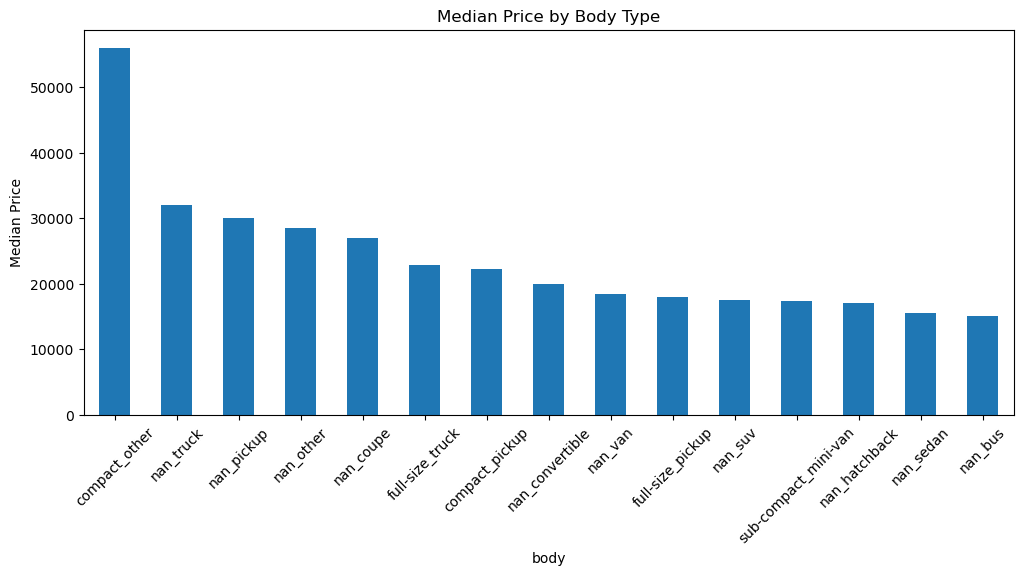

In [200]:
df.groupby('body')['price'].median().sort_values(ascending=False)

body_prices = df.groupby('body')['price'].median().sort_values(ascending=False).head(15)

body_prices.plot(kind='bar', figsize=(12,5), title='Median Price by Body Type')
plt.ylabel('Median Price')
plt.xticks(rotation=45)
plt.show()



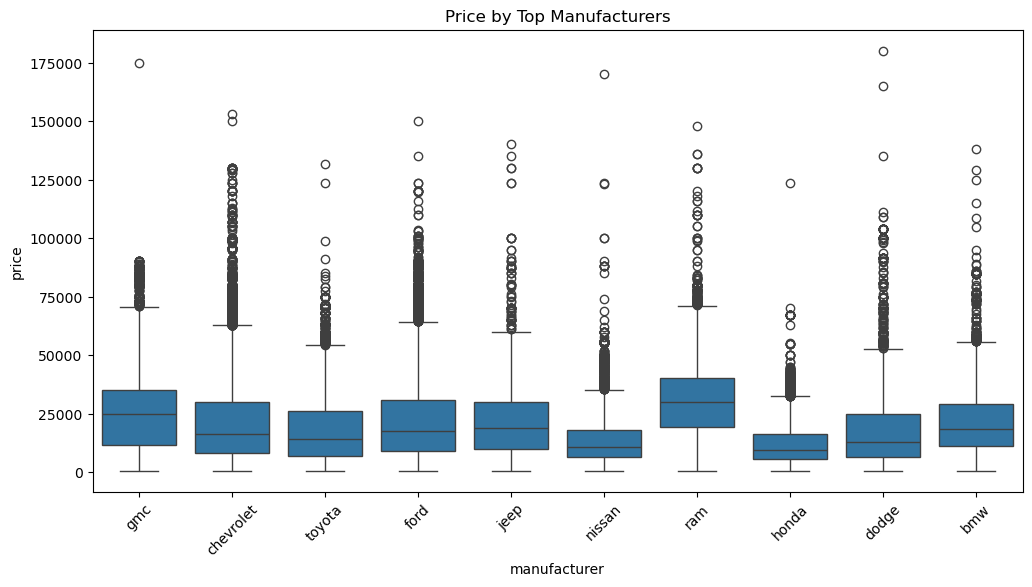

In [201]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['manufacturer'].isin(df['manufacturer'].value_counts().head(10).index)],
            x='manufacturer', y='price')
plt.xticks(rotation=45)
plt.title("Price by Top Manufacturers")
plt.show()


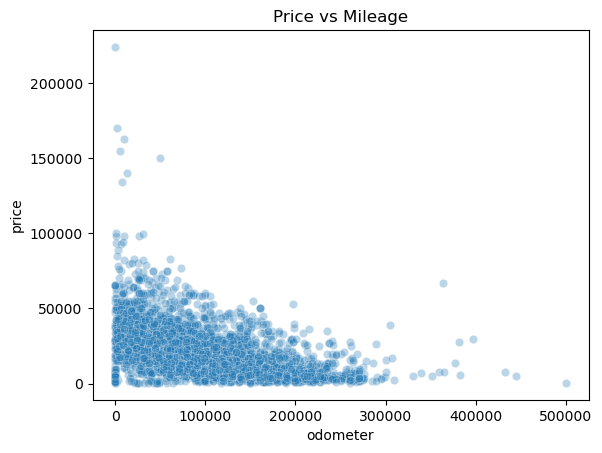

In [202]:
#this displays a strong negative relationship, odometer is essential
sns.scatterplot(data=df.sample(5000), x='odometer', y='price', alpha=0.3)
plt.title("Price vs Mileage")
plt.show()

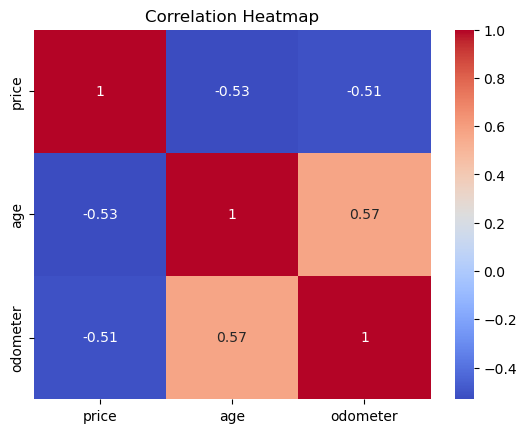

In [102]:
numeric_cols = ['price', 'age', 'odometer']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


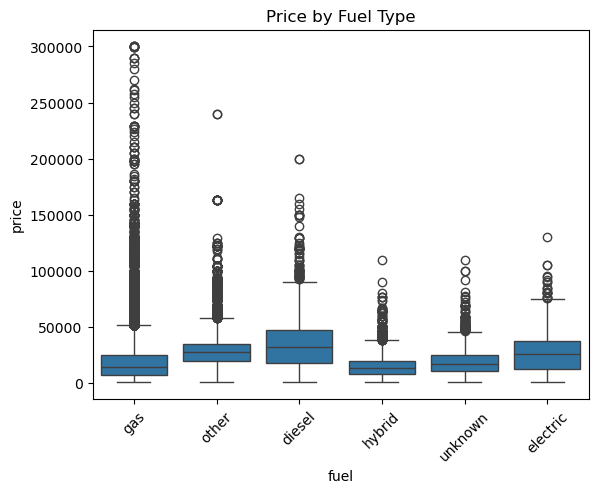

In [203]:
#This is rather interesting, I was expecting hybrid cars to have a higher price tag
sns.boxplot(data=df, x='fuel', y='price')
plt.xticks(rotation=45)
plt.title("Price by Fuel Type")
plt.show()


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [204]:
#Without going into the code, based on dealership knowledge and industry norms, we can determine strongest price drivers (What do customers care about when buying a used car?):
numeric_features = ["age", "odometer", "miles_per_year", "condition_num"]
categorical_features = ["manufacturer", "model", "fuel", "body"]
target = "log_price"


In [205]:
#Fill Null values with unknown for categorical features
for col in categorical_features:
    df[col] = df[col].fillna("unknown")

In [206]:
#Fill Null values with the median for Numerical features
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

In [207]:
#Fix miles_per_year edge cases
df['miles_per_year'] = df['odometer'] / df['age'].replace(0, np.nan)
df['miles_per_year'] = df['miles_per_year'].fillna(df['miles_per_year'].median())

In [208]:
df['log_price'] = np.log(df['price'])
df['log_price'] = df['log_price'].fillna(df['log_price'].median())

In [149]:
df[numeric_features + categorical_features + ['log_price']].isnull().sum()

age               0
odometer          0
miles_per_year    0
condition_num     0
manufacturer      0
model             0
fuel              0
body              0
log_price         0
dtype: int64

In [210]:

df['log_price'] = np.log(df['price'])

X = df[numeric_features + categorical_features]
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(296639, 8)
(74160, 8)
(296639,)
(74160,)


In [211]:
# even after initial cleanup, there is NaN somewhere and hence will have to go back to and clean the data again, there are some outlier values that would have caused errors 
#Second execution resulted in all 0's
X.isnull().sum().sort_values(ascending=False)

age               0
odometer          0
miles_per_year    0
condition_num     0
manufacturer      0
model             0
fuel              0
body              0
dtype: int64

In [212]:

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scale", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False))
        ]), numeric_features),
        
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

set_config(display='diagram')

preprocessor_poly

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [213]:

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=5000)
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor_poly),
        ("model", model)
    ])
    for name, model in models.items()
}


In [215]:
# even after initial cleanup, there is NaN somewhere and henc, this was giving an error, so will have to go back to Data Preperation step and review
from sklearn.metrics import r2_score, mean_squared_error

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    results[name] = {
        "R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    }

results


{'Linear': {'R2': 0.7684978154035607, 'RMSE': np.float64(0.4257553510956025)},
 'Ridge': {'R2': 0.7718604574805668, 'RMSE': np.float64(0.422651925089784)},
 'Lasso': {'R2': 0.6623377260011143, 'RMSE': np.float64(0.5141902516202002)}}

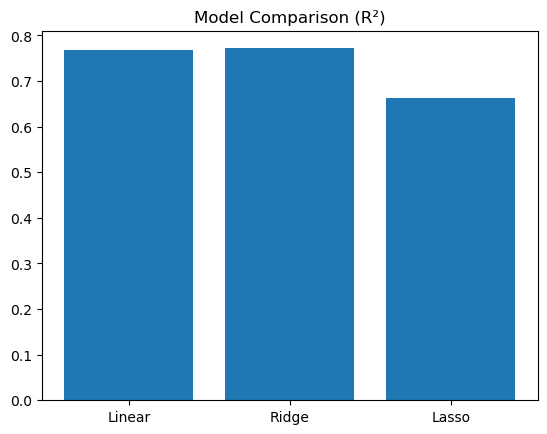

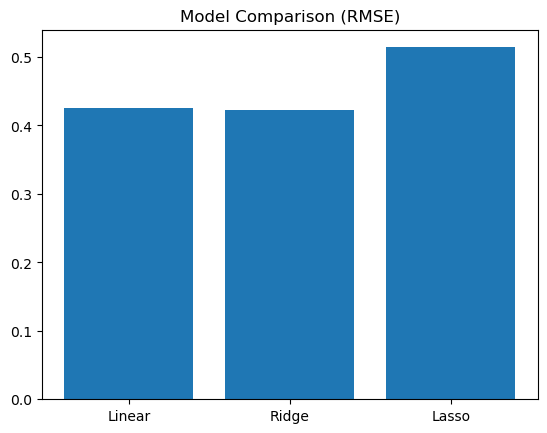

In [216]:
plt.bar(results.keys(), [v["R2"] for v in results.values()])
plt.title("Model Comparison (R²)")
plt.show()

plt.bar(results.keys(), [v["RMSE"] for v in results.values()])
plt.title("Model Comparison (RMSE)")
plt.show()


### Model Comparison Summary

**Ridge and Linear Regression show similar performance.  
Lasso has lower R² and higher RMSE.**

---

### Why Linear and Ridge perform similarly

- The relationships in the data are mostly **linear**  
- Polynomial features (degree=2) help **a little**, but not dramatically  
- Multicollinearity from polynomial features is **not severe**, so Ridge does not outperform Linear  
- The numeric features are already **strong predictors** without heavy nonlinear expansion  

---

### Why Lasso performs worse

- Lasso is **over‑penalizing** the coefficients  
- It is **removing useful polynomial terms**  
- It shrinks aggressively, causing **loss of predictive power**  
- The dataset likely has **many correlated features**, and Lasso struggles with correlated inputs  


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [217]:

for d in [1, 2, 3]:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    pipe = Pipeline([
        ("preprocess", ColumnTransformer([
            ("num", Pipeline([
                ("scale", StandardScaler()),
                ("poly", poly)
            ]), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ])),
        ("model", Ridge(alpha=1.0))
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    print(f"Degree {d}: mean R2 = {scores.mean():.4f}")


Degree 1: mean R2 = 0.7525
Degree 2: mean R2 = 0.7678
Degree 3: mean R2 = 0.7730


Based on the data above, degree 2 will give god performance with reasonable number of features, still easy to interpret. Degree 3 only change the outcome by 0.5%. 
Now we train our final Ridge model with degree 2 polynomial features This becomes the production candidate model.



In [218]:
#Final Ridge model, Degree 2 Poluynomial Features

ridge_final = Pipeline([
    ("preprocess", preprocessor_poly),
    ("model", Ridge(alpha=1.0))
])

ridge_final.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [219]:
#Get Feature Names 
poly_features = ridge_final.named_steps["preprocess"] \
    .named_transformers_["num"] \
    .named_steps["poly"] \
    .get_feature_names_out(numeric_features)

cat_features = ridge_final.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

all_features = list(poly_features) + list(cat_features)


In [220]:
importance = pd.DataFrame({
    "feature": all_features,
    "coef": ridge_final.named_steps["model"].coef_
}).sort_values(by="coef", ascending=False)


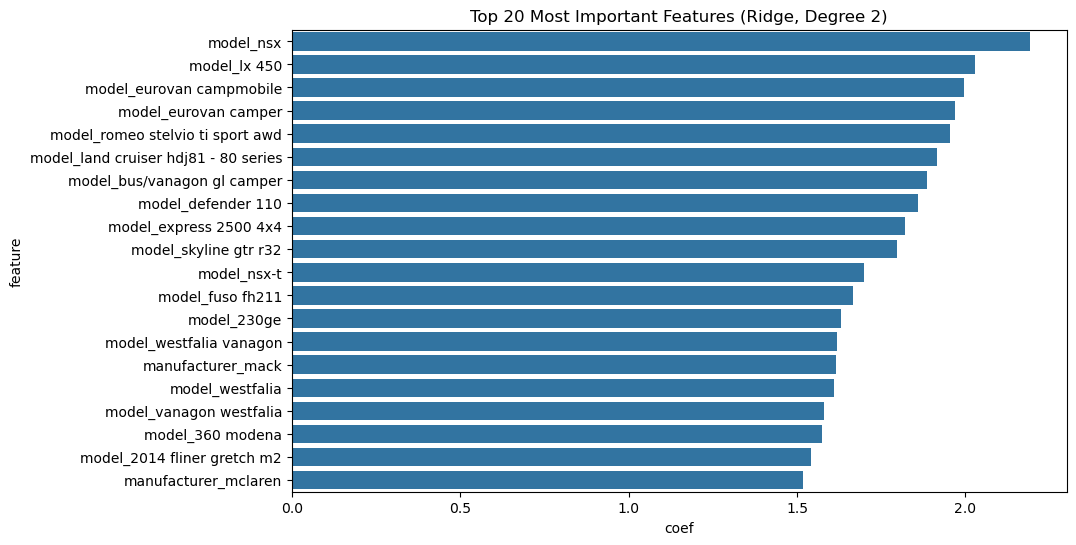

In [221]:
top20 = importance.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x='coef', y='feature')
plt.title("Top 20 Most Important Features (Ridge, Degree 2)")
plt.show()


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.


### Executive Summary
Our analysis of over 400,000 used‑car listings reveals clear, data‑driven patterns in what drives vehicle prices. Using a Ridge regression model with nonlinear features, we identified the strongest predictors of price and how they influence consumer willingness to pay. These insights directly support smarter purchasing, pricing, reconditioning decisions.

**Top Price Drivers (Based on Model Coefficients + Domain Logic)**

**1.** Manufacturer & Model 
Models like Eurovan, Lexus, Land Cruiser, along with many vans, campers, and wagons, consistently exhibit higher price influence than expected along with Popular models (F‑150, Camry, Civic, Silverado)    
Business Impact: Stock high‑demand models to improve turnover and margins.

**2.** Vehicle Age
Younger vehicles command significantly higher prices. Price declines rapidly in the first few years, then stabilizes.  
Business Impact: Prioritize vehicles with lower age for best resale margins.

**3.** Mileage
Lower mileage strongly increases value. Penalty is steep early but flattens after ~120K miles.  
Business Impact: Vehicles with <60K miles offer the strongest profit potential.

**4.** Usage Intensity (Miles per Year)
A lightly driven vehicle is valued more than one with heavy annual usage.  
Business Impact: Highlight **“low annual mileage”** in listings; adjust pricing for high‑usage vehicles.

**5.** Condition Rating
Condition is one of the strongest predictors of price.  
Business Impact: Invest in reconditioning when it moves a vehicle up a condition tier.

**6.** Body Type (Engineered Feature)
SUVs, Vans and trucks consistently outperform sedans and coupes.  
Business Impact: Increase inventory of SUVs and trucks; price sedans more competitively.

**7.** Fuel Type 
Hybrids and EVs show higher median prices than gas vehicles.  
Business Impact: Expand hybrid/EV inventory where demand supports it.


#### Recommendations for Inventory Strategy
**Buy**
- Late‑model vehicles 
- Low‑mileage inventory (<60K miles)
- SUVs, Vans and trucks
- Top performer models along with mainstream vehicles
- Hybrids and EVs in strong markets only

**Avoid**
- High‑mileage sedans unless priced aggressively
- Vehicles with “fair” or “salvage” condition
- Rare or niche models with low demand

**Recondition**
- Vehicles close to “excellent” condition
- Cosmetic improvements that move a car up one condition tier

#### Conclusion
Consumers value newer, lower‑mileage, well‑maintained vehicles from reputable brands, especially SUVs, Vans and trucks.
Your dealership can improve margins and turnover by focusing inventory acquisition on these segments and pricing vehicles according to their strongest value drivers.
